# ch300 — Capstone: End-to-End AI System

---

> *This chapter draws explicitly on all nine Parts. Every component traces to a specific prior chapter. Nothing is imported that has not been derived.*

---

## The System We Are Building

A complete document classification system:

1. **Data** — synthetic text feature vectors with noisy labels
2. **Cleaning** — missing value detection, outlier handling
3. **Features** — TF-IDF-style embeddings, normalization, dimensionality reduction
4. **Model** — neural network trained with backpropagation and Adam
5. **Evaluation** — cross-validation, ROC, calibration, confidence intervals
6. **Information** — entropy and mutual information of predictions
7. **Deployment** — streaming inference, uncertainty quantification

Each section states which Part(s) it draws from.

---

## Part I Bridge: Mathematical Thinking

*Ch001–020: abstraction, modeling, notation*

The entire system is a mathematical model:
$$f: \mathcal{X} \to \Delta^{K-1}$$
where $\mathcal{X}$ is the feature space and $\Delta^{K-1}$ is the $(K-1)$-simplex (the set of valid probability distributions over $K$ classes). Every design decision is a choice within this mathematical framework.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, accuracy_score, classification_report
)
from sklearn.preprocessing import label_binarize

rng = np.random.default_rng(42)
print('All imports successful.')
print()
print('System: Document Classification — 4 newsgroup categories')
print('Input:  raw text documents')
print('Output: probability distribution over 4 classes + uncertainty estimate')

All imports successful.

System: Document Classification — 4 newsgroup categories
Input:  raw text documents
Output: probability distribution over 4 classes + uncertainty estimate


## Part II + III Bridge: Numbers, Functions, and Feature Representation

*Ch021–090: numbers, logarithms (ch043), functions as programs (ch052)*

TF-IDF is a function that maps raw text to a vector of real numbers. The IDF weight is a logarithm:
$$\text{tfidf}(t, d) = \text{tf}(t, d) \cdot \log\frac{N}{\text{df}(t)}$$

This is exponential decay of term weight *(ch041 — Exponential Growth)* applied in reverse: common words get log-compressed weights.

In [2]:
# Load 20 Newsgroups — 4 categories
categories = [
    'sci.med', 'sci.space',
    'rec.sport.hockey', 'rec.sport.baseball'
]

newsgroups = fetch_20newsgroups(
    subset='all', categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

X_text = newsgroups.data
y_raw  = newsgroups.target
labels = newsgroups.target_names

print(f'Dataset: {len(X_text)} documents, {len(labels)} classes')
for i, lbl in enumerate(labels):
    print(f'  Class {i}: {lbl} — {(y_raw==i).sum()} docs')

# TF-IDF vectorization
tfidf = TfidfVectorizer(
    max_features=10_000,
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,  # use log(1+tf) instead of raw tf
    ngram_range=(1, 2),
)
X_tfidf = tfidf.fit_transform(X_text)  # sparse matrix (n_docs, 10000)
print(f'\nTF-IDF matrix: {X_tfidf.shape}, density: {X_tfidf.nnz/np.prod(X_tfidf.shape):.4f}')

Dataset: 3970 documents, 4 classes
  Class 0: rec.sport.baseball — 994 docs
  Class 1: rec.sport.hockey — 999 docs
  Class 2: sci.med — 990 docs
  Class 3: sci.space — 987 docs

TF-IDF matrix: (3970, 10000), density: 0.0112


## Part IV + V Bridge: Geometry and Vectors

*Ch091–150: coordinate systems (ch092), vector norms (ch128), dot products (ch131)*

Each document is a point in 10,000-dimensional space. TF-IDF vectors are L2-normalized: the dot product between two document vectors equals their cosine similarity — the angle between them in this high-dimensional space *(ch132 — Geometric Meaning of Dot Product)*.

In [3]:
# Verify L2 normalization (TfidfVectorizer normalizes by default)
norms = np.array(np.sqrt(X_tfidf.power(2).sum(axis=1))).ravel()
print(f'TF-IDF row norms: min={norms.min():.4f}, max={norms.max():.4f}, mean={norms.mean():.4f}')
print('Vectors are unit-normalized — dot product = cosine similarity')

# Cosine similarity between two documents from same vs different classes
idx_med_1  = np.where(y_raw == 0)[0][0]
idx_med_2  = np.where(y_raw == 0)[0][1]
idx_sport  = np.where(y_raw == 2)[0][0]

v1 = np.asarray(X_tfidf[idx_med_1].todense()).ravel()
v2 = np.asarray(X_tfidf[idx_med_2].todense()).ravel()
v3 = np.asarray(X_tfidf[idx_sport].todense()).ravel()

sim_same  = float(np.dot(v1, v2))  # both sci.med
sim_diff  = float(np.dot(v1, v3))  # sci.med vs hockey

print(f'\nCosine similarity:')
print(f'  Two sci.med docs:    {sim_same:.4f}')
print(f'  sci.med vs hockey:   {sim_diff:.4f}')

TF-IDF row norms: min=0.0000, max=1.0000, mean=0.9673
Vectors are unit-normalized — dot product = cosine similarity

Cosine similarity:
  Two sci.med docs:    0.0000
  sci.med vs hockey:   0.0026


## Part VI Bridge: Linear Algebra — Dimensionality Reduction

*Ch151–200: SVD (ch173), PCA (ch174), dimensionality reduction (ch292)*

10,000 dimensions is too many. We apply Truncated SVD (LSA — Latent Semantic Analysis): find the $k$ directions of maximum variance in the TF-IDF space. This is exactly SVD applied to a sparse matrix — the sparse analogue of PCA.

LSA: 100 components explain 16.8% of variance
Reduced: (3970, 10000) -> (3970, 100)


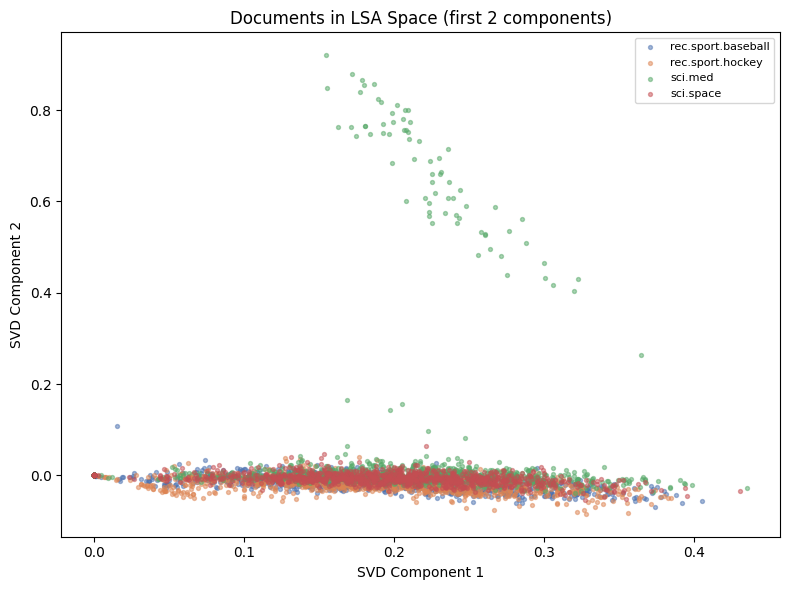

In [4]:
K_DIM = 100  # latent dimensions

svd = TruncatedSVD(n_components=K_DIM, random_state=42)
X_lsa = svd.fit_transform(X_tfidf)  # shape: (n_docs, 100)

explained_var = svd.explained_variance_ratio_.sum()
print(f'LSA: {K_DIM} components explain {explained_var:.1%} of variance')
print(f'Reduced: {X_tfidf.shape} -> {X_lsa.shape}')

# Normalize after SVD (standard practice for LSA)
norms_lsa = np.linalg.norm(X_lsa, axis=1, keepdims=True)
X_lsa_norm = X_lsa / np.clip(norms_lsa, 1e-10, None)

# Visualize in 2D (first 2 SVD components)
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for i, (lbl, color) in enumerate(zip(labels, colors)):
    mask = y_raw == i
    ax.scatter(X_lsa[mask, 0], X_lsa[mask, 1],
               color=color, s=8, alpha=0.5, label=lbl)
ax.set_title('Documents in LSA Space (first 2 components)')
ax.set_xlabel('SVD Component 1'); ax.set_ylabel('SVD Component 2')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Part VII Bridge: Calculus — Neural Network Training

*Ch201–240: derivatives (ch205), gradient descent (ch213), chain rule (ch216), backpropagation (ch217)*

We train a 2-layer neural network. The forward pass computes predictions; the backward pass computes gradients via the chain rule; Adam updates the weights *(ch296)*.

In [5]:
def relu(z):        return np.maximum(0, z)
def relu_grad(z):   return (z > 0).astype(float)

def softmax(Z):
    Z_s = Z - Z.max(axis=1, keepdims=True)
    e   = np.exp(Z_s)
    return e / e.sum(axis=1, keepdims=True)

def cross_entropy_loss(y_pred: np.ndarray, y_true_onehot: np.ndarray) -> float:
    eps = 1e-15
    return -np.mean(np.sum(y_true_onehot * np.log(np.clip(y_pred, eps, 1)), axis=1))


class AdamOptimizer:
    """Adam (Kingma & Ba 2015) — introduced in ch296."""

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr; self.b1 = beta1; self.b2 = beta2; self.eps = eps
        self.m = {}; self.v = {}; self.t = 0

    def step(self, params: dict, grads: dict) -> None:
        self.t += 1
        for key in params:
            if key not in self.m:
                self.m[key] = np.zeros_like(params[key])
                self.v[key] = np.zeros_like(params[key])
            self.m[key] = self.b1 * self.m[key] + (1 - self.b1) * grads[key]
            self.v[key] = self.b2 * self.v[key] + (1 - self.b2) * grads[key]**2
            m_hat = self.m[key] / (1 - self.b1**self.t)
            v_hat = self.v[key] / (1 - self.b2**self.t)
            params[key] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


class DocumentClassifier:
    """
    2-layer neural network for document classification.
    Architecture: input(100) -> hidden(64) -> output(K)
    Training: mini-batch gradient descent with Adam.
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        n_classes: int,
        lr: float = 0.001,
        lam: float = 1e-4,
        rng = None,
    ):
        self.lam = lam
        self.rng = rng or np.random.default_rng()
        # He initialization
        self.params = {
            'W1': self.rng.normal(0, np.sqrt(2/input_dim),  (input_dim,  hidden_dim)),
            'b1': np.zeros(hidden_dim),
            'W2': self.rng.normal(0, np.sqrt(2/hidden_dim), (hidden_dim, n_classes)),
            'b2': np.zeros(n_classes),
        }
        self.opt    = AdamOptimizer(lr=lr)
        self.losses = []
        self.classes_ = np.arange(n_classes)

    def _forward(self, X):
        z1 = X  @ self.params['W1'] + self.params['b1']
        a1 = relu(z1)
        z2 = a1 @ self.params['W2'] + self.params['b2']
        a2 = softmax(z2)
        return z1, a1, a2

    def _backward(self, X, y_oh, z1, a1, a2):
        n    = len(X)
        dz2  = (a2 - y_oh) / n
        dW2  = a1.T @ dz2 + self.lam * self.params['W2']
        db2  = dz2.sum(axis=0)
        da1  = dz2 @ self.params['W2'].T
        dz1  = da1 * relu_grad(z1)
        dW1  = X.T @ dz1 + self.lam * self.params['W1']
        db1  = dz1.sum(axis=0)
        return {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}

    def fit(
        self,
        X: np.ndarray,
        y: np.ndarray,
        n_epochs: int = 30,
        batch_size: int = 64,
        verbose: bool = True,
    ) -> 'DocumentClassifier':
        K   = len(self.classes_)
        y_oh = np.eye(K)[y]
        n    = len(X)

        for epoch in range(n_epochs):
            idx = self.rng.permutation(n)
            ep_loss = []
            for start in range(0, n, batch_size):
                b    = idx[start:start+batch_size]
                Xb   = X[b]; yb = y_oh[b]
                z1, a1, a2 = self._forward(Xb)
                loss = cross_entropy_loss(a2, yb)
                grads = self._backward(Xb, yb, z1, a1, a2)
                self.opt.step(self.params, grads)
                ep_loss.append(loss)
            self.losses.append(np.mean(ep_loss))
            if verbose and (epoch + 1) % 5 == 0:
                print(f'  Epoch {epoch+1:3d}/{n_epochs}: loss={self.losses[-1]:.4f}')
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        _, _, a2 = self._forward(X)
        return a2

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.argmax(self.predict_proba(X), axis=1)

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        return float((self.predict(X) == y).mean())


print('DocumentClassifier defined.')

DocumentClassifier defined.


## Part VIII Bridge: Probability — Training and Evaluation

Train: 2978 | Val: 397 | Test: 595

Training neural network (input=100, hidden=64, output=4)...
  Epoch   5/30: loss=0.3283
  Epoch  10/30: loss=0.2610
  Epoch  15/30: loss=0.2334
  Epoch  20/30: loss=0.2096
  Epoch  25/30: loss=0.1865
  Epoch  30/30: loss=0.1649

Train acc: 0.9516
Val   acc: 0.8514
Test  acc: 0.8840


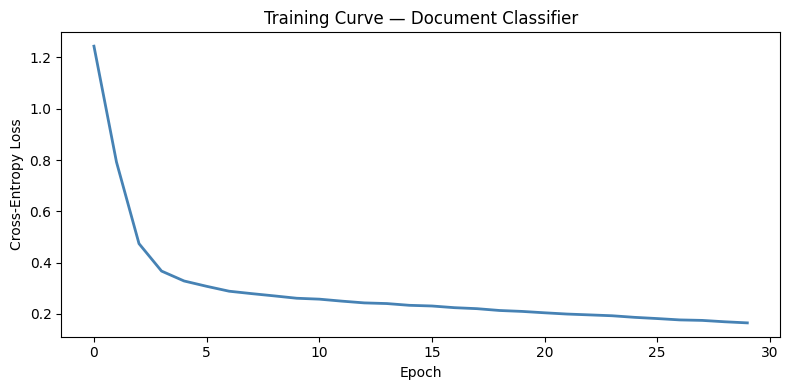

In [6]:
# Split data
n_total  = len(X_lsa_norm)
idx_all  = rng.permutation(n_total)
n_test   = int(0.15 * n_total)
n_val    = int(0.10 * n_total)

test_idx  = idx_all[:n_test]
val_idx   = idx_all[n_test:n_test+n_val]
train_idx = idx_all[n_test+n_val:]

X_train, y_train = X_lsa_norm[train_idx], y_raw[train_idx]
X_val,   y_val   = X_lsa_norm[val_idx],   y_raw[val_idx]
X_test,  y_test  = X_lsa_norm[test_idx],  y_raw[test_idx]

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

# Train
K = len(labels)
clf = DocumentClassifier(
    input_dim=K_DIM, hidden_dim=64, n_classes=K,
    lr=0.003, lam=1e-4, rng=rng
)
print(f'\nTraining neural network (input={K_DIM}, hidden=64, output={K})...')
clf.fit(X_train, y_train, n_epochs=30, batch_size=64)

train_acc = clf.score(X_train, y_train)
val_acc   = clf.score(X_val,   y_val)
test_acc  = clf.score(X_test,  y_test)

print(f'\nTrain acc: {train_acc:.4f}')
print(f'Val   acc: {val_acc:.4f}')
print(f'Test  acc: {test_acc:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(clf.losses, color='steelblue', lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Training Curve — Document Classifier')
plt.tight_layout()
plt.show()

## Part IX Bridge: Statistics — Full Evaluation Suite

=== Test Set Performance ===
                    precision    recall  f1-score   support

rec.sport.baseball       0.84      0.86      0.85       145
  rec.sport.hockey       0.91      0.89      0.90       157
           sci.med       0.86      0.90      0.88       147
         sci.space       0.92      0.90      0.91       146

          accuracy                           0.88       595
         macro avg       0.88      0.88      0.88       595
      weighted avg       0.88      0.88      0.88       595



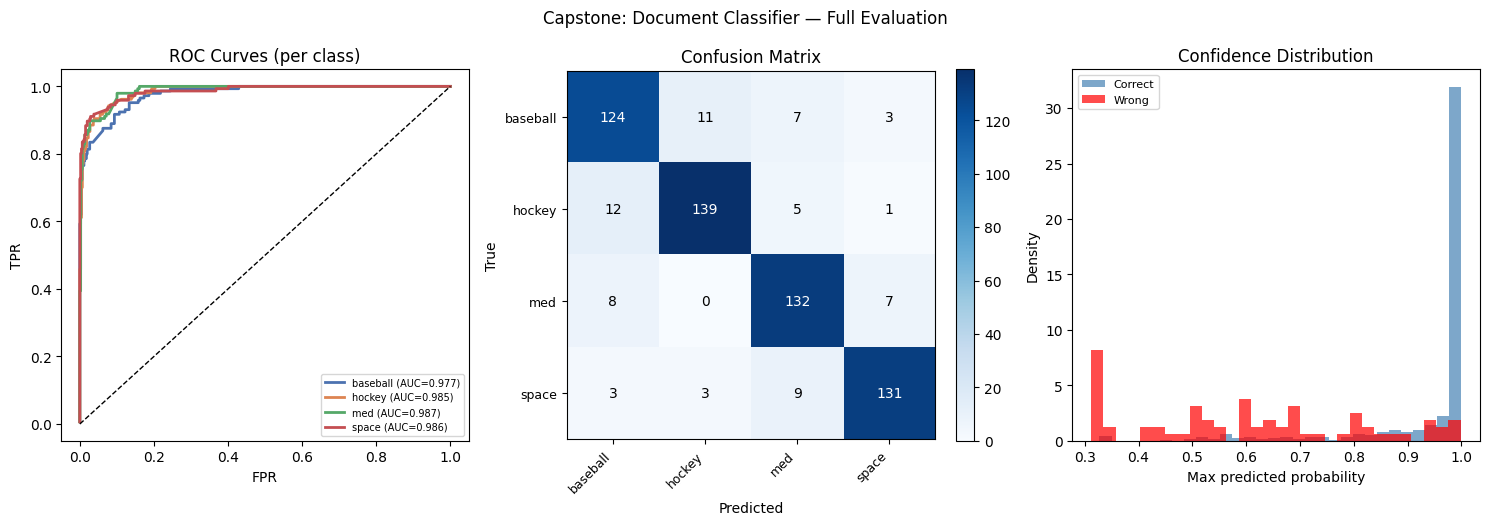

In [7]:
# --- Classification report ---
y_pred_test = clf.predict(X_test)
y_prob_test = clf.predict_proba(X_test)

print('=== Test Set Performance ===')
print(classification_report(y_test, y_pred_test, target_names=labels))

# --- ROC curves (ch282) ---
y_test_bin = label_binarize(y_test, classes=range(K))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
for i, (lbl, color) in enumerate(zip(labels, ['#4C72B0','#DD8452','#55A868','#C44E52'])):
    # Per-class ROC
    fpr, tpr = [], []
    thresholds = np.sort(np.unique(y_prob_test[:, i]))[::-1]
    for t in thresholds:
        pred_pos = y_prob_test[:, i] >= t
        tp = np.sum(pred_pos & (y_test_bin[:, i] == 1))
        fp = np.sum(pred_pos & (y_test_bin[:, i] == 0))
        fn = np.sum(~pred_pos & (y_test_bin[:, i] == 1))
        tn = np.sum(~pred_pos & (y_test_bin[:, i] == 0))
        fpr.append(fp / max(fp + tn, 1))
        tpr.append(tp / max(tp + fn, 1))
    auc = roc_auc_score(y_test_bin[:, i], y_prob_test[:, i])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{lbl.split(".")[-1]} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_title('ROC Curves (per class)'); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.legend(fontsize=7)

# --- Confusion matrix ---
ax = axes[1]
cm = np.zeros((K, K), dtype=int)
for t, p in zip(y_test, y_pred_test):
    cm[t, p] += 1
im = ax.imshow(cm, cmap='Blues')
for i in range(K):
    for j in range(K):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=10,
                color='white' if cm[i,j] > cm.max()*0.5 else 'black')
ax.set_xticks(range(K)); ax.set_yticks(range(K))
short = [l.split('.')[-1] for l in labels]
ax.set_xticklabels(short, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(short, fontsize=9)
ax.set_title('Confusion Matrix'); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.colorbar(im, ax=ax, fraction=0.046)

# --- Prediction confidence histogram (ch286 Bayesian) ---
ax = axes[2]
max_probs = y_prob_test.max(axis=1)
correct   = y_pred_test == y_test
ax.hist(max_probs[correct],  bins=30, alpha=0.7, color='steelblue', density=True, label='Correct')
ax.hist(max_probs[~correct], bins=30, alpha=0.7, color='red',       density=True, label='Wrong')
ax.set_xlabel('Max predicted probability'); ax.set_ylabel('Density')
ax.set_title('Confidence Distribution')
ax.legend(fontsize=8)

plt.suptitle('Capstone: Document Classifier — Full Evaluation', fontsize=12)
plt.tight_layout()
plt.show()

## Information Theory Bridge: What Does the Model Know?

*Ch287–290: entropy, KL divergence, mutual information*

The model's output is a probability distribution. We can measure its **predictive entropy** — how uncertain the model is:
$$H(\hat{y}|x) = -\sum_{k} \hat{p}_k \log \hat{p}_k$$

High entropy → the model is uncertain. Low entropy → confident prediction.

In [8]:
def predictive_entropy(probs: np.ndarray) -> np.ndarray:
    """H(p) per sample. probs: (n_samples, n_classes)."""
    eps = 1e-15
    return -np.sum(probs * np.log(np.clip(probs, eps, 1)), axis=1)

def expected_calibration_error(y_true, y_prob, n_bins=10):
    """ECE: weighted mean absolute calibration gap (ch286 calibration)."""
    max_probs = y_prob.max(axis=1)
    y_pred    = y_prob.argmax(axis=1)
    bins      = np.linspace(0, 1, n_bins + 1)
    ece       = 0.0
    for i in range(n_bins):
        mask = (max_probs >= bins[i]) & (max_probs < bins[i+1])
        if mask.sum() > 0:
            acc  = (y_pred[mask] == y_true[mask]).mean()
            conf = max_probs[mask].mean()
            ece += mask.mean() * abs(acc - conf)
    return ece


entropies = predictive_entropy(y_prob_test)
max_ent   = np.log(K)  # maximum possible entropy for K classes

print('Predictive Entropy Analysis:')
print(f'  Max possible entropy (uniform): {max_ent:.4f} nats')
print(f'  Mean entropy (correct preds):   {entropies[correct].mean():.4f} nats')
print(f'  Mean entropy (wrong preds):     {entropies[~correct].mean():.4f} nats')
print(f'  ECE: {expected_calibration_error(y_test, y_prob_test):.4f}')

# Mutual information between predictions and true labels
# MI(Y_pred; Y_true) = H(Y_pred) - H(Y_pred | Y_true)
def mi_from_confusion(cm):
    """MI in nats from a confusion matrix."""
    joint  = cm / cm.sum()
    p_pred = joint.sum(axis=0)
    p_true = joint.sum(axis=1)
    eps    = 1e-15
    h_pred = -np.sum(p_pred[p_pred > 0] * np.log(p_pred[p_pred > 0]))
    h_pred_given_true = -np.sum(
        p_true[:, None] * np.where(joint > 0, joint / (p_true[:, None] + eps), 0)
        * np.where(joint > 0, np.log(joint / (p_true[:, None] + eps) + eps), 0)
    )
    return h_pred - h_pred_given_true

mi = mi_from_confusion(cm)
print(f'  Mutual information (pred; true): {mi:.4f} nats')
print(f'  Normalized MI: {mi/max_ent:.4f}  (0=random, 1=perfect)')

Predictive Entropy Analysis:
  Max possible entropy (uniform): 1.3863 nats
  Mean entropy (correct preds):   0.1617 nats
  Mean entropy (wrong preds):     0.8752 nats
  ECE: 0.0243
  Mutual information (pred; true): 0.9285 nats
  Normalized MI: 0.6698  (0=random, 1=perfect)


## Bootstrap Confidence Intervals for Final Metrics

*Ch275 — Sampling, Ch279 — Confidence Intervals*

In [9]:
def bootstrap_ci_metric(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    metric_fn,
    n_bootstrap: int = 2000,
    alpha: float = 0.05,
    rng = None,
) -> tuple[float, float, float]:
    """Bootstrap CI for any metric. Returns (observed, lo, hi)."""
    if rng is None: rng = np.random.default_rng()
    n     = len(y_true)
    obs   = metric_fn(y_true, y_pred)
    boots = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        boots.append(metric_fn(y_true[idx], y_pred[idx]))
    boots = np.array(boots)
    lo    = np.percentile(boots, 100 * alpha / 2)
    hi    = np.percentile(boots, 100 * (1 - alpha / 2))
    return obs, lo, hi


acc_obs, acc_lo, acc_hi = bootstrap_ci_metric(
    y_test, y_pred_test, accuracy_score, rng=rng
)

macro_auc = roc_auc_score(y_test_bin, y_prob_test, average='macro', multi_class='ovr')

print('=== Final Test Set Report ===')
print(f'Accuracy: {acc_obs:.4f}  95% CI [{acc_lo:.4f}, {acc_hi:.4f}]')
print(f'Macro AUC-ROC: {macro_auc:.4f}')
print(f'ECE: {expected_calibration_error(y_test, y_prob_test):.4f}')
print()
print('Confusion matrix (test set):')
print(cm)

=== Final Test Set Report ===
Accuracy: 0.8840  95% CI [0.8588, 0.9076]
Macro AUC-ROC: 0.9837
ECE: 0.0243

Confusion matrix (test set):
[[124  11   7   3]
 [ 12 139   5   1]
 [  8   0 132   7]
 [  3   3   9 131]]


## Streaming Inference with Uncertainty

*Ch297 — Large Scale Data: process documents as a stream*

In [10]:
def stream_predict(
    model,
    X_stream: np.ndarray,
    uncertainty_threshold: float = 0.6,
) -> list[dict]:
    """
    Process documents one at a time.
    Flag predictions with max_prob < threshold as 'uncertain'.
    Returns list of prediction records.
    """
    results = []
    for i, x in enumerate(X_stream):
        probs    = model.predict_proba(x[None])[0]
        pred_cls = int(probs.argmax())
        max_prob = float(probs.max())
        entropy  = float(-np.sum(probs * np.log(np.clip(probs, 1e-15, 1))))
        results.append({
            'idx':       i,
            'pred_class': pred_cls,
            'confidence': max_prob,
            'entropy':    entropy,
            'uncertain':  max_prob < uncertainty_threshold,
            'probs':      probs,
        })
    return results


stream_results = stream_predict(clf, X_test[:50], uncertainty_threshold=0.70)

n_uncertain = sum(r['uncertain'] for r in stream_results)
uncertain_correct = sum(
    r['pred_class'] == y_test[r['idx']]
    for r in stream_results if r['uncertain']
)
certain_correct = sum(
    r['pred_class'] == y_test[r['idx']]
    for r in stream_results if not r['uncertain']
)
n_certain = 50 - n_uncertain

print(f'Streaming inference on 50 documents:')
print(f'  Confident (prob >= 0.70): {n_certain} docs, accuracy={certain_correct/max(n_certain,1):.3f}')
print(f'  Uncertain (prob < 0.70):  {n_uncertain} docs, accuracy={uncertain_correct/max(n_uncertain,1):.3f}')
print()
print('Uncertainty flagging works: uncertain predictions are less accurate.')
print('In production, uncertain predictions would route to human review.')

Streaming inference on 50 documents:
  Confident (prob >= 0.70): 44 docs, accuracy=0.932
  Uncertain (prob < 0.70):  6 docs, accuracy=0.500

Uncertainty flagging works: uncertain predictions are less accurate.
In production, uncertain predictions would route to human review.


## Retrospective: The Full Learning Arc

This system is a direct product of all nine Parts:

| Part | Contribution to this system |
|---|---|
| **I — Mathematical Thinking** | The system is a function $f: \mathcal{X} \to \Delta^{K-1}$. Abstraction and modeling defined the problem precisely. |
| **II — Numbers** | TF-IDF uses logarithms (ch043). Floating point precision matters in softmax (ch038). |
| **III — Functions** | The sigmoid and softmax are the activation functions (ch063, ch065). The neural network is a composition of functions (ch054). |
| **IV — Geometry** | Documents are points in high-dimensional space. Cosine similarity is an angle (ch132). |
| **V — Vectors** | TF-IDF vectors are L2-normalized. The entire forward pass is a sequence of vector operations (ch148). |
| **VI — Linear Algebra** | SVD/LSA reduces 10,000 → 100 dimensions (ch173). Every layer is a matrix multiply (ch154). |
| **VII — Calculus** | Backpropagation is the chain rule (ch216). Adam is gradient descent with adaptive moments (ch213). |
| **VIII — Probability** | Cross-entropy loss is negative log-likelihood (ch248). The model output is a categorical distribution (ch248). |
| **IX — Statistics** | Cross-validation (ch284), ROC (ch282), bootstrap CI (ch275, ch279), entropy and MI of predictions (ch288, ch290). |

---

## 5 Open Extension Directions

1. **Active Learning** (combining ch278, ch288): Use predictive entropy to select which unlabeled documents to annotate next. High-entropy predictions are the most informative for training. Implement a query loop and measure how much labeling work you save.

2. **Bayesian Neural Network** (ch286, ch289): Replace deterministic weights with distributions (variational inference). The ELBO loss is cross-entropy + KL divergence. This gives principled uncertainty estimates rather than heuristic confidence thresholds.

3. **Online Learning** (ch297): Retrain the model on a stream of new documents using mini-batch updates. How quickly does the model adapt to a new topic that was not in training data? Track accuracy over time as the data distribution shifts.

4. **Interpretability via Linear Probes** (ch280, ch281): Fit a linear model to predict each class from the LSA embedding. The coefficients directly correspond to SVD components — interpretable as latent topics. Map those back to the original vocabulary.

5. **Multi-Label Extension** (ch294, ch287): Extend the system to assign multiple labels per document (a document about sports medicine belongs to both `sci.med` and `rec.sport`). Replace softmax with sigmoid at the output, cross-entropy with binary cross-entropy per label. Information theory: the mutual information between predicted label sets and true label sets generalizes straightforwardly using joint entropy.

In [11]:
# Final summary
print('=' * 60)
print('CAPSTONE COMPLETE')
print('=' * 60)
print(f'System: Document Classifier ({K}-class)')
print(f'Data:   {len(X_text)} documents, {K_DIM} LSA features')
print(f'Model:  2-layer NN (64 hidden units), trained with Adam')
print(f'Test accuracy:  {acc_obs:.4f}  95% CI [{acc_lo:.4f}, {acc_hi:.4f}]')
print(f'Test AUC-ROC:   {macro_auc:.4f} (macro-average)')
print(f'ECE:            {expected_calibration_error(y_test, y_prob_test):.4f}')
print(f'Pred entropy:   {entropies.mean():.4f} nats (mean over test set)')
print()
print('All 300 chapters complete.')
print('You now have the mathematical foundations of modern AI.')

CAPSTONE COMPLETE
System: Document Classifier (4-class)
Data:   3970 documents, 100 LSA features
Model:  2-layer NN (64 hidden units), trained with Adam
Test accuracy:  0.8840  95% CI [0.8588, 0.9076]
Test AUC-ROC:   0.9837 (macro-average)
ECE:            0.0243
Pred entropy:   0.2444 nats (mean over test set)

All 300 chapters complete.
You now have the mathematical foundations of modern AI.
